# unittest – Practice Exercises

Hands-on exercises for Python's `unittest` framework, following `g_unittest.ipynb`.

### Contents

- [Exercise 1 – Basic TestCase and Assertions](#exercise-1--basic-testcase-and-assertions)
- [Exercise 2 – Testing Pure Functions](#exercise-2--testing-pure-functions)
- [Exercise 3 – setUp and tearDown](#exercise-3--setup-and-teardown)
- [Exercise 4 – Testing Classes and State](#exercise-4--testing-classes-and-state)
- [Exercise 5 – Mocking and Patching](#exercise-5--mocking-and-patching)
- [Exercise 6 – Mocking Time and Randomness](#exercise-6--mocking-time-and-randomness)
- [Exercise 7 – Parameterized Tests with subTest](#exercise-7--parameterized-tests-with-subtest)
- [Exercise 8 – Test Organization and Discovery](#exercise-8--test-organization-and-discovery)
- [Exercise 9 – Running Tests: CLI, Verbosity, and pytest](#exercise-9--running-tests-cli-verbosity-and-pytest)
- [Exercise 10 – Best Practices](#exercise-10--best-practices)

## Exercise 1 – Basic TestCase and Assertions

**Goal**: Write your first test class.

**Requirements**:

- Create a `TestBasicMath` class inheriting from `unittest.TestCase`.
- Add `test_addition`, `test_subtraction`, and `test_type_error` methods.
- Run with `unittest.main(argv=[''], exit=False)` inside the notebook.

**Hint**: `self.assertRaises(ErrorType)` can be used as a context manager.

In [133]:
from unittest import TestCase, TestLoader, TextTestRunner

class TestBasicMath(TestCase):

    def test_add(self): self.assertEqual(1 + 1, 2)
    def test_sub(self): self.assertEqual(1 - 1, 0)
    def test_err(self):
        with self.assertRaises(ZeroDivisionError): x = 1/0

test = TestBasicMath
loader = TestLoader().loadTestsFromTestCase(test)
result = TextTestRunner(verbosity = 2).run(loader)
print("Tests run:", result.testsRun, "Failures:", len(result.failures))

test_add (__main__.TestBasicMath.test_add) ... ok
test_err (__main__.TestBasicMath.test_err) ... ok
test_sub (__main__.TestBasicMath.test_sub) ... ok

----------------------------------------------------------------------
Ran 3 tests in 0.002s

OK


Tests run: 3 Failures: 0


---
---
---
## CLASSES FOR TESTING

In [134]:
import os, sys, numpy, asyncio, aiohttp, requests
from pandas import Series, DataFrame, Index, concat
from pandas import Timestamp, Timedelta, date_range
from dataclasses import dataclass

from typing import Any, List, Tuple, Dict, Set, Callable
from unittest import TestCase, TestLoader, TextTestResult
from unittest.mock import patch, Mock, AsyncMock
from enum import Enum

In [135]:
@dataclass(frozen = True) ## SYMBOL
class Symbol:
    venue: str; symbol: str
    point: float; digits: int; min_qty: float = 0.01
    bod: Timedelta = None; eod: Timedelta = None
    @classmethod
    def sample(cls):
        curs = ["EUR", "GBP", "AUD", "NZD", "USD", "CAD", "CHF"]
        symbol = str.join("", numpy.random.choice(curs, 2, False))
        return cls("OANDA", symbol, 0.00001, 5)
    @property
    def tradable(self):
        now = Timestamp.utcnow()
        dnow = now - now.floor("1D")
        return (None in [self.bod, self.bod]) \
            or (self.bod <= dnow < self.eod) \
            or (dnow < self.eod <= self.bod) \
            or (self.eod <= self.bod < dnow)

In [136]:
@dataclass(frozen = True) ## TICK
class Tick:
    pa: float; pb: float; va: float; vb: float
    venue: str; symbol: str; time: Timestamp = None
    def __post_init__(self):
        if self.time is None:
            self.time = Timestamp.utcnow()
    @property
    def str_data(self):
        return f"A{self.va:.2f}@{self.pa:.5f} B{self.vb:.2f}@{self.pb:.5f}"
    def __repr__(self):
        time = self.time.isoformat(" ", "microseconds")[: 26]
        return f"Tick({time} :: {self.venue}|{self.symbol} :: {self.str_data})"

In [137]:
@dataclass(frozen = True) ## OHLC
class OHLC:
    timestamp: Timestamp; timeframe: Timedelta
    open: float; high: float; low: float; close: float
    @classmethod
    def from_series(cls, ts: Series, tf: Timedelta = None):
        pl, ph = sys.float_info.max, sys.float_info.min
        to = Timestamp.max.tz_localize("UTC")
        tc = Timestamp.min.tz_localize("UTC")
        for time, value in ts.items():
            if (tc < time): pc, tc = value, time
            if (time < to): po, to = value, time
            if (ph < value): ph = value
            if (pl > value): pl = value
        if (tf is None): tf = tc - to
        else: to = to.floor(tf)
        return cls(to, tf, float(po), float(ph), float(pl), float(pc))

In [138]:
@dataclass(frozen = True) ## CANDLE
class Candle:
    symbol: Symbol; ask: OHLC; bid: OHLC
    vavg: float; vwap: float; tvol: int
    def __post_init__(self):
        now = Timestamp.utcnow()
        object.__setattr__(self, "time", now)
    @classmethod
    def from_ticks(cls, df: DataFrame, symbol: Symbol = None, tf: Timedelta = None):
        if symbol is None: symbol = Symbol.sample()
        is_ask = df.columns.str.contains("a", regex = True)
        is_bid = df.columns.str.contains("b", regex = True)
        is_price = df.columns.str.contains("p", regex = True)
        is_vol = df.columns.str.contains("q|v", regex = True)
        column_ap: str = df.columns[is_ask & is_price][0]
        column_bp: str = df.columns[is_bid & is_price][0]
        column_av: str = df.columns[is_ask & is_vol][0]
        column_bv: str = df.columns[is_bid & is_vol][0]
        df_ap, df_av = df[column_ap], df[column_av].diff().abs()
        df_bp, df_bv = df[column_bp], df[column_bv].diff().abs()
        ask, bid = OHLC.from_series(df_ap, tf), OHLC.from_series(df_bp, tf)
        vwap = Series.mean((df_ap * df_av + df_bp * df_bv) / (df_av + df_bv))
        vwap = float(round(vwap, symbol.digits))
        vavg = int(Series.mean(df_av + df_bv))
        return cls(symbol, ask, bid, vavg, vwap, df.shape[0])
    @classmethod
    def sample(cls, size: int = 12345, pgen = 1.23456,
               tf: Timedelta = Timedelta(minutes = 1)):
        tgen = Timestamp.utcnow().floor(tf)
        index = date_range(tgen, tgen + tf, size + 1)
        df = DataFrame(index = index[: -1])
        columns = ["ap", "bp", "av", "bv"]
        df[columns] = numpy.random.randn(size, 4)
        delta = pow(10, int(numpy.log10(pgen / size) - 2))
        df["bp"] = numpy.sign(df["bp"].shift()).cumsum()
        df["ap"] = (df["ap"] * 5).abs().round()
        df["bp"] = delta * df["bp"].fillna(0) + pgen
        df["ap"] = delta * (df["ap"] + 1) + df["bp"]
        df["av"] = ((df["av"] * 50).abs() + size).astype(int)
        df["bv"] = ((df["bv"] * 50).abs() + size).astype(int)
        return cls.from_ticks(df, tf = tf)

In [170]:
@dataclass(frozen = True) ## ORDER
class Order:
    quantity: float
    symbol: Symbol
    price: float = None
    def __post_init__(self):
        if abs(self.quantity) < (min_qty := self.symbol.min_qty):
            error = f"\"{abs(self.quantity):.2f} < {min_qty}\""
            raise ValueError(f"Quantity below min: " + error)
        _type: Order.Type = None if self.price else Order.Type.MARKET
        _side: Order.Side = Order.Side(int(numpy.sign(self.quantity)))
        quantity = round(abs(self.quantity) / min_qty) * min_qty
        object.__setattr__(self, "quantity", quantity)
        object.__setattr__(self, "_type", _type)
        object.__setattr__(self, "_side", _side)

    class Side(Enum): BUY, SELL = +1, -1
    class Type(Enum): MARKET, LIMIT, STOP = 0, -1, +1
    class Status(Enum): PLACED, PENDING, CANCELLED, REJECTED = 0, 1, 2, 3

    @property
    def type(self): return self._type
    @property
    def side(self): return self._side
    def on_price(self, price: float):
        assert isinstance(price, float) and (price > 0)
        _side: Order.Side = object.__getattribute__(self, "_side")
        _type: Order.Type = object.__getattribute__(self, "_type")
        if _type: object.__setattr__(self, "price", price)
        dist = (self.price - price) * _side.value
        _type = Order.Type(numpy.sign(dist))
        object.__setattr__(self, "_type", _type) 

In [140]:
class Binance: ## BINANCE/HTTP

    BASE_URL = "https://api.binance.com/api/v3"

    @classmethod
    def log(cls, *args):
        t = Timestamp.utcnow()
        ts = t.strftime("%H:%M:%S.%f")
        print(f"[{ts[: -3]}]", *args)
        return t

    @classmethod
    async def _request(cls, session: aiohttp.ClientSession,
                semaphore: asyncio.Semaphore, args: dict):

        async with semaphore:
            async with session.get(**args) as response:
                try: response.raise_for_status()
                except Exception as EXC:
                    cls.log(f"Response error: \"{EXC!r}\"")
                    return None
                try: data = await response.json()
                except Exception as EXC:
                    cls.log(f"Resp data error: \"{EXC!r}\"")
                    return None
                return data

    @classmethod
    async def price(cls, symbols: List[str], timeout: float = 2, max_threads: int = 4):

        args = dict[str, Any](
            url = f"{cls.BASE_URL}/ticker/price",
            timeout = aiohttp.ClientTimeout(timeout))
        
        semaphore = asyncio.Semaphore(max_threads)
        async with aiohttp.ClientSession() as session:
            tasks = dict.fromkeys(symbols)
            for symbol in symbols:
                args["params"] = {"symbol": symbol}
                future = cls._request(session, semaphore, args.copy())
                tasks[symbol] = asyncio.create_task(future)
            results = dict(zip(
                symbols, await asyncio.gather(*tasks.values())))
            return {K: float(V["price"]) for K, V in results.items()}

---
---
---

## Exercise 2 – Testing Pure Functions

**Goal**: Test a pricing/PnL utility with multiple assertions.

**Requirements**:

- Write `calc_pnl(entry, exit_, qty)` and `calc_notional(price, qty)`.
- Write a `TestPnL` suite covering normal values, zero qty, and negative PnL.
- Use `assertAlmostEqual` for floating-point comparisons.

**Hint**: `assertAlmostEqual(a, b, places=6)` avoids float precision issues.

In [141]:
class TestCandle(TestCase):
    P_GEN = 1.23456
    CANDLE = Candle.sample(pgen = P_GEN)
    def test_ohlc(self):
        self.assertAlmostEqual(self.P_GEN, self.CANDLE.bid.open)
        self.assertLessEqual(self.CANDLE.bid.open, self.CANDLE.bid.high)
        self.assertLessEqual(self.CANDLE.bid.close, self.CANDLE.bid.high)
        self.assertGreaterEqual(self.CANDLE.bid.open, self.CANDLE.bid.low)
        self.assertGreaterEqual(self.CANDLE.bid.close, self.CANDLE.bid.low)
    def test_bid_ask(self):
        self.assertLess(self.CANDLE.bid.open, self.CANDLE.ask.open)
        self.assertLess(self.CANDLE.bid.high, self.CANDLE.ask.high)
        self.assertLess(self.CANDLE.bid.low, self.CANDLE.ask.low)
        self.assertLess(self.CANDLE.bid.close, self.CANDLE.ask.close)

test = TestCandle
loader = TestLoader().loadTestsFromTestCase(test)
result = TextTestRunner(verbosity = 2).run(loader)
print("Tests run:", result.testsRun, "Failures:", len(result.failures))

test_bid_ask (__main__.TestCandle.test_bid_ask) ... ok
test_ohlc (__main__.TestCandle.test_ohlc) ... ok

----------------------------------------------------------------------
Ran 2 tests in 0.002s

OK


Tests run: 2 Failures: 0


## Exercise 3 – setUp and tearDown

**Goal**: Share state between tests using fixtures.

**Requirements**:

- Create a `TestOrderBook` suite that builds a fresh `dict` order book in `setUp`.
- Write tests that add, remove, and query orders, relying on the clean state each time.
- Add a `tearDown` that prints the remaining order count.

**Hint**: `setUp` runs before every single test method; `setUpClass` runs once for the whole class.

In [142]:
class TestCandle(TestCandle):
    def setUp(self):
        self.candle = Candle.sample(10, 1.23456)
    def test_vwap(self):
        self.assertFalse(self.CANDLE.vwap < self.CANDLE.bid.low)
        self.assertTrue(self.CANDLE.vwap < self.CANDLE.bid.high)

test = TestCandle
loader = TestLoader().loadTestsFromTestCase(test)
result = TextTestRunner(verbosity = 2).run(loader)
print("Tests run:", result.testsRun, "Failures:", len(result.failures))

test_bid_ask (__main__.TestCandle.test_bid_ask) ... ok
test_ohlc (__main__.TestCandle.test_ohlc) ... ok
test_vwap (__main__.TestCandle.test_vwap) ... ok

----------------------------------------------------------------------
Ran 3 tests in 0.009s

OK


Tests run: 3 Failures: 0


## Exercise 4 – Testing Classes and State

**Goal**: Test a stateful class over a sequence of operations.

**Requirements**:

- Write a minimal `Position(symbol, qty=0)` class with `buy(qty)`, `sell(qty)`, and `is_flat` property.
- Write `TestPosition` with tests for buy, sell, over-sell raising `ValueError`, and `is_flat`.

**Hint**: Test one behavior per test method; use descriptive names like `test_sell_below_zero_raises`.

In [143]:
import os, sys, numpy
from enum import Enum
from unittest import TestCase, TestLoader, TextTestRunner
from dataclasses import dataclass, asdict
from typing import Any, List, Dict, Set, Callable

class TestOrder(TestCase):
    def setUp(self):
        self.symbol = Symbol.sample()
        self.quantity = 0.52

    def test_zero_qty(self):
        with self.assertRaises(ValueError):
            Order(0, self.symbol, 1.23445)
    def test_market_buy(self):
        price_order, price_last = None, 1.23456
        order = Order(+ self.quantity, self.symbol, price_order)
        self.assertEqual(order.side, Order.Side.BUY)
        order.on_price(price_last)
        self.assertEqual(order.type, Order.Type.MARKET)
    def test_market_sell(self):
        price_order, price_last = None, 1.23456
        order = Order(- self.quantity, self.symbol, price_order)
        self.assertEqual(order.side, Order.Side.SELL)
        order.on_price(price_last)
        self.assertEqual(order.type, Order.Type.MARKET)
    def test_limit_buy(self):
        price_order, price_last = 1.23356, 1.23456
        order = Order(+ self.quantity, self.symbol, price_order)
        self.assertEqual(order.side, Order.Side.BUY)
        order.on_price(price_last)
        self.assertEqual(order.type, Order.Type.LIMIT)
    def test_limit_sell(self):
        price_order, price_last = 1.23556, 1.23456
        order = Order(- self.quantity, self.symbol, price_order)
        self.assertEqual(order.side, Order.Side.SELL)
        order.on_price(price_last)
        self.assertEqual(order.type, Order.Type.LIMIT)
    def test_stop_buy(self):
        price_order, price_last = 1.23556, 1.23456
        order = Order(+ self.quantity, self.symbol, price_order)
        self.assertEqual(order.side, Order.Side.BUY)
        order.on_price(price_last)
        self.assertEqual(order.type, Order.Type.STOP)
    def test_stop_sell(self):
        price_order, price_last = 1.23356, 1.23456
        order = Order(- self.quantity, self.symbol, price_order)
        self.assertEqual(order.side, Order.Side.SELL)
        order.on_price(price_last)
        self.assertEqual(order.type, Order.Type.STOP)

# Run the tests for this suite
test = TestOrder
loader = TestLoader().loadTestsFromTestCase(test)
result = TextTestRunner(verbosity = 2).run(loader)
print("Tests run:", result.testsRun, "Failures:", len(result.failures))

test_limit_buy (__main__.TestOrder.test_limit_buy) ... ok
test_limit_sell (__main__.TestOrder.test_limit_sell) ... ok
test_market_buy (__main__.TestOrder.test_market_buy) ... ok
test_market_sell (__main__.TestOrder.test_market_sell) ... ok
test_stop_buy (__main__.TestOrder.test_stop_buy) ... ok
test_stop_sell (__main__.TestOrder.test_stop_sell) ... ok
test_zero_qty (__main__.TestOrder.test_zero_qty) ... ok

----------------------------------------------------------------------
Ran 7 tests in 0.004s

OK


Tests run: 7 Failures: 0


## Exercise 5 – Mocking and Patching

**Goal**: Replace external dependencies with controlled fakes.

**Requirements**:

- Write a function `get_price(symbol)` that calls `requests.get(...)` and returns a float.
- In `TestGetPrice`, use `unittest.mock.patch('requests.get')` to avoid real HTTP calls.
- Test both a successful response and a `requests.ConnectionError`.

**Hint**: `patch` replaces the target at the *import site* of your module, not at `requests` itself.

In [144]:
def get_price(symbol):
    BASE_URL = "https://api.binance.com/api/v3/"
    URL = BASE_URL + "ticker/price?symbol=" + symbol
    response = requests.get(URL)
    data = response.json()
    return float(data[symbol])

class TestGetPrice(TestCase):
    @patch("requests.get")
    def test_successful(self, mock_get):
        symbol = "BTCUSDT"
        price_val = 67000.0
        mock_resp = Mock()
        mock_resp.json.return_value = {symbol: price_val}
        mock_get.return_value = mock_resp
        self.assertEqual(get_price(symbol), price_val)

    @patch("requests.get")
    def test_error_conn(self, mock_get):
        mock_get.side_effect = requests.ConnectionError
        with self.assertRaises(requests.ConnectionError):
            get_price("BTCUSDT")

# Run the tests for this suite
test = TestGetPrice
loader = TestLoader().loadTestsFromTestCase(test)
result = TextTestRunner(verbosity = 2).run(loader)
print("Tests run:", result.testsRun, "Failures:", len(result.failures))

test_error_conn (__main__.TestGetPrice.test_error_conn) ... ok
test_successful (__main__.TestGetPrice.test_successful) ... ok

----------------------------------------------------------------------
Ran 2 tests in 0.002s

OK


Tests run: 2 Failures: 0


## Exercise 6 – Mocking Time and Randomness

**Goal**: Control non-deterministic behavior in tests.

**Requirements**:

- Write `time_window_open()` that returns `True` only during 09:30-16:00 UTC.
- Patch `Timestamp.utcnow` to return a fixed time and test both branches.
- Also patch `random.random` to test a function that rejects trades below a threshold.

**Hint**: Use `@patch('module.datetime')` rather than patching the stdlib directly.

In [145]:
class TestClass(TestCase):
    T0930 = Timedelta("09:30:00")
    T1200 = Timedelta("12:00:00")
    T1700 = Timedelta("16:00:00")
    T2330 = Timedelta("23:30:00")
    @patch("pandas.Timestamp.utcnow")
    def test_tradable_fixed(self, mock_utcnow):
        symbol = Symbol(venue = "OANDA", symbol = "EURUSD", digits = 5,
                  point = 0.00001, bod = self.T0930, eod = self.T1700)
        # Setup: Market open at 09:35, market closed at 08:00
        # Market open
        mock_utcnow.return_value = Timestamp.now().floor("1D") + symbol.bod * 1.1
        self.assertTrue(symbol.tradable, mock_utcnow.return_value.strftime("%H:%M"))
        # Market closed
        mock_utcnow.return_value = Timestamp.now().floor("1D") + symbol.eod * 1.1
        self.assertFalse(symbol.tradable, mock_utcnow.return_value.strftime("%H:%M"))
        # On boundary (09:30:00)
        mock_utcnow.return_value = Timestamp.now().floor("1D") + symbol.bod * 1.0
        self.assertTrue(symbol.tradable, mock_utcnow.return_value.strftime("%H:%M"))
        # On boundary (16:00:00)
        mock_utcnow.return_value = Timestamp.now().floor("1D") + symbol.eod * 1.0
        self.assertFalse(symbol.tradable, mock_utcnow.return_value.strftime("%H:%M"))
        # Just after close
        mock_utcnow.return_value = Timestamp.now().floor("1D") + symbol.eod * 1.00001
        self.assertFalse(symbol.tradable, mock_utcnow.return_value.strftime("%H:%M"))
    @patch("pandas.Timestamp.utcnow")
    def test_tradable_random(self, mock_utcnow):
        symbol = Symbol(venue = "OANDA", symbol = "EURUSD", digits = 5,
                        point = 0.00001, bod = self.T2330, eod = self.T1200)
        rn = numpy.random.random()
        fake_time = self.T1200 * 0.95 + (self.T2330 - self.T1200) * rn * 1.05
        mock_utcnow.return_value = Timestamp.now().floor("1D") + fake_time
        sbod, seod, sfake = str(symbol.bod), str(symbol.eod), str(fake_time)
        print(f"Values... BOD: {sbod[7:12]}, EOD: {seod[7:12]}, TIME: {sfake[7:12]}")
        self.assertFalse(symbol.tradable, mock_utcnow.return_value.strftime("%H:%M"))

# Running the tests for exercise 6
test = TestClass
suite = TestLoader().loadTestsFromTestCase(test)
result = TextTestRunner(verbosity = 2).run(suite)
print("Tests run:", result.testsRun, "Failures:", len(result.failures))

test_tradable_fixed (__main__.TestClass.test_tradable_fixed) ... ok
test_tradable_random (__main__.TestClass.test_tradable_random) ... ok

----------------------------------------------------------------------
Ran 2 tests in 0.005s

OK


Values... BOD: 23:30, EOD: 12:00, TIME: 16:39
Tests run: 2 Failures: 0


## Exercise 7 – Parameterized Tests with subTest

**Goal**: Run the same logic over many inputs without duplicating test methods.

**Requirements**:

- Write `validate_order(symbol, qty, price)` that raises `ValueError` for invalid inputs.
- In one test method, use `with self.subTest(case=...)` to iterate over a table of (symbol, qty, price, should_raise) tuples.
- Confirm all invalid cases raise and all valid cases pass.

**Hint**: `subTest` lets multiple failures surface in one run instead of stopping at the first.

In [146]:
class TestClass(TestCase):
    TODAY = Timestamp.utcnow().floor("1D")
    @patch("pandas.Timestamp.utcnow")
    def test_tradable(self, mock_utcnow):
        for _ in range(10):
            bod = numpy.random.random() * Timedelta("1D")
            eod = numpy.random.random() * Timedelta("1D")
            fake = numpy.random.random() * Timedelta("1D") + self.TODAY
            case = dict(BOD = str(bod)[7:12],
              TIME = str(fake)[11:16], EOD = str(eod)[7:12])
            with self.subTest(case = case):
                symbol = Symbol("OANDA", "EURUSD", 0.00001, 5, 0.01, bod, eod)
                mock_utcnow.return_value = fake
                self.assertTrue(symbol.tradable)

# Running the tests for exercise 7
test = TestClass
suite = TestLoader().loadTestsFromTestCase(test)
result = TextTestRunner(verbosity = 2).run(suite)
print("Tests run:", result.testsRun, "Failures:", len(result.failures))

test_tradable (__main__.TestClass.test_tradable) ... 
  test_tradable (__main__.TestClass.test_tradable) (case={'BOD': '03:04', 'TIME': '00:31', 'EOD': '08:02'}) ... FAIL
  test_tradable (__main__.TestClass.test_tradable) (case={'BOD': '15:33', 'TIME': '11:49', 'EOD': '06:15'}) ... FAIL
  test_tradable (__main__.TestClass.test_tradable) (case={'BOD': '16:49', 'TIME': '02:00', 'EOD': '00:18'}) ... FAIL

FAIL: test_tradable (__main__.TestClass.test_tradable) (case={'BOD': '03:04', 'TIME': '00:31', 'EOD': '08:02'})
----------------------------------------------------------------------
Traceback (most recent call last):
  File "C:\Users\GSL\AppData\Local\Temp\ipykernel_51612\1863210967.py", line 14, in test_tradable
    self.assertTrue(symbol.tradable)
    ~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
AssertionError: False is not true

FAIL: test_tradable (__main__.TestClass.test_tradable) (case={'BOD': '15:33', 'TIME': '11:49', 'EOD': '06:15'})
---------------------------------------------------------

Tests run: 1 Failures: 3


## Exercise 8 – Test Organization and Discovery

**Goal**: Structure tests so `python -m unittest discover` finds them.

**Requirements**:

- Print a directory tree: `tests/__init__.py`, `tests/test_pricing.py`, `tests/test_orders.py`.
- Write the `discover` CLI command that runs only files matching `test_*.py`.
- Explain when to use `TestLoader.loadTestsFromModule` vs discovery.

**Hint**: `python -m unittest discover -s tests -p 'test_*.py'` is the standard incantation.

In [147]:
# Directory structure for test organization
print("""
tests/
├── __init__.py
├── test_pricing.py
└── test_orders.py
""")

# Discover CLI command (standard usage):
print("unittest discover command to find tests:")
print("python -m unittest discover -s tests -p 'test_*.py'")

# Loader method vs discovery explanation:
print("""
- Use `unittest.TestLoader().loadTestsFromModule(module)` when:
    * You want to specify *exactly* which modules or tests to load and run, often in a script or Jupyter notebook.
    * Useful for fine control or ad-hoc/interactive runs.
- Use discovery (`python -m unittest discover ...`) when:
    * You want all tests in files named `test_*.py` under a folder (e.g., for automation, CI, project-wide checks).
    * Automatically collects all tests from files and subdirectories matching the pattern.
""")


tests/
├── __init__.py
├── test_pricing.py
└── test_orders.py

unittest discover command to find tests:
python -m unittest discover -s tests -p 'test_*.py'

- Use `unittest.TestLoader().loadTestsFromModule(module)` when:
    * You want to specify *exactly* which modules or tests to load and run, often in a script or Jupyter notebook.
    * Useful for fine control or ad-hoc/interactive runs.
- Use discovery (`python -m unittest discover ...`) when:
    * You want all tests in files named `test_*.py` under a folder (e.g., for automation, CI, project-wide checks).
    * Automatically collects all tests from files and subdirectories matching the pattern.



In [148]:
import subprocess

# Example: Run unittest discovery via subprocess (cross-platform)
cmd = ["python", "-m", "unittest", "discover", "-s", "tests", "-p", "test_*.py"]
result = subprocess.run(cmd, capture_output = True, text = True)
print("unittest discover output (via subprocess):\n", result.stdout)
if result.stderr: print("Errors:\n", result.stderr)

unittest discover output (via subprocess):
 
Errors:
 2026-04-04 02:43:05,065 matplotlib data path: c:\DEV\Python\Lib\site-packages\matplotlib\mpl-data
2026-04-04 02:43:05,068 CONFIGDIR=C:\Users\GSL\.matplotlib
2026-04-04 02:43:05,093 interactive is False
2026-04-04 02:43:05,093 platform is win32
2026-04-04 02:43:05,122 CACHEDIR=C:\Users\GSL\.matplotlib
2026-04-04 02:43:05,124 Using fontManager instance from C:\Users\GSL\.matplotlib\fontlist-v390.json
EEEE
ERROR: test_binary_option (tests.test_Binary_Option.TestBinaryOption.test_binary_option)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "c:\DEV\Python\Lib\site-packages\tests\test_Binary_Option.py", line 14, in test_binary_option
    I_want_money.change_balance("PRACTICE")
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
  File "c:\DEV\Python\Lib\site-packages\iqoptionapi\stable_api.py", line 432, in change_balance
    for balance in self.get_profile_ansyc()["balances"]:
  

## Exercise 9 – Running Tests: CLI, Verbosity, and pytest

**Goal**: Explore different ways to run a suite.

**Requirements**:

- Run the `TestPnL` suite from Exercise 2 with verbosity=2 using `TextTestRunner`.
- Show the equivalent `pytest` command for the same file.
- Print the key differences between `unittest` and `pytest` output formats.

**Hint**: pytest automatically collects `unittest.TestCase` subclasses with no extra config.

## Exercise 10 – Best Practices

**Goal**: Apply quality guidelines to a trading test suite.

**Requirements**:

- Write a `TestRiskCheck` class demonstrating: one assertion per test, descriptive method names, no print statements, and `assertLogs` to capture log output.
- Add a `skip` decorator to a test that requires a live market connection.

**Hint**: `@unittest.skip('reason')` and `@unittest.skipIf(condition, reason)` keep suites green in CI.

In [171]:
import unittest

symbol = "BTCUSDT"
response = await Binance.price([symbol], 10)
price = response[symbol]

class TestRiskCheck(unittest.TestCase):
    def setUp(self):
        self.symbol = Symbol("Binance", symbol, 0.01, 2, 0.0001)
        print(self.symbol.min_qty)

    def test_order_types(self):
        # One assertion per test, descriptive name
        cases = [
            {"quantity": +0.01, "price_diff": None, "side": Order.Side.BUY, "type": Order.Type.MARKET},
            {"quantity": -0.01, "price_diff": None, "side": Order.Side.SELL, "type": Order.Type.MARKET},
            {"quantity": +0.01, "price_diff": +0.01, "side": Order.Side.BUY, "type": Order.Type.STOP},
            {"quantity": -0.01, "price_diff": +0.01, "side": Order.Side.SELL, "type": Order.Type.LIMIT},
            {"quantity": +0.01, "price_diff": -0.01, "side": Order.Side.BUY, "type": Order.Type.LIMIT},
            {"quantity": -0.01, "price_diff": -0.01, "side": Order.Side.SELL, "type": Order.Type.STOP},
        ]
        for case in cases:
            with self.subTest(case = case):
                quantity, price_diff, order_side, order_type = case.values()
                order_price = price * (1 + price_diff) if price_diff else None
                order = Order(quantity, self.symbol, order_price)
                order.on_price(price)
                self.assertEqual(order.side, order_side)
                self.assertEqual(order.type, order_type)

    @unittest.skipIf(True, 'needs live market connection')
    def test_market_status_flag_set_live(self):
        # This is just for demonstration; would require real integration
        order = Order(self.symbol.min_qty, self.symbol, price * 1.05)
        status = self.venue.send(order)["status"]
        self.assertEqual(status, Order.Status.PLACED)

test = TestRiskCheck
suite = TestLoader().loadTestsFromTestCase(test)
result = TextTestRunner(verbosity = 3).run(suite)
print("Tests run:", result.testsRun, "Failures:", len(result.failures))

test_market_status_flag_set_live (__main__.TestRiskCheck.test_market_status_flag_set_live) ... skipped 'needs live market connection'
test_order_types (__main__.TestRiskCheck.test_order_types) ... ok

----------------------------------------------------------------------
Ran 2 tests in 0.003s

OK (skipped=1)


0.0001
Tests run: 2 Failures: 0


---
---
---
## Trash zone

,mret,sret,xret,cret,bal,ddn
time,,,,,,
2026/04,0.000027,0.001526,2.617096,2.617096,26170.96,0.145425
2026/05,0.000022,0.001518,5.535021,14.485682,144856.82,0.152072
2026/06,0.000030,0.001526,10.576248,153.204164,1532041.64,0.117539
2026/07,0.000026,0.001524,8.275408,1267.826900,12678269.00,0.206277
2026/08,0.000031,0.001515,3.640004,4614.894775,46148947.75,0.155730


Max DDN: 0.20627660091225009


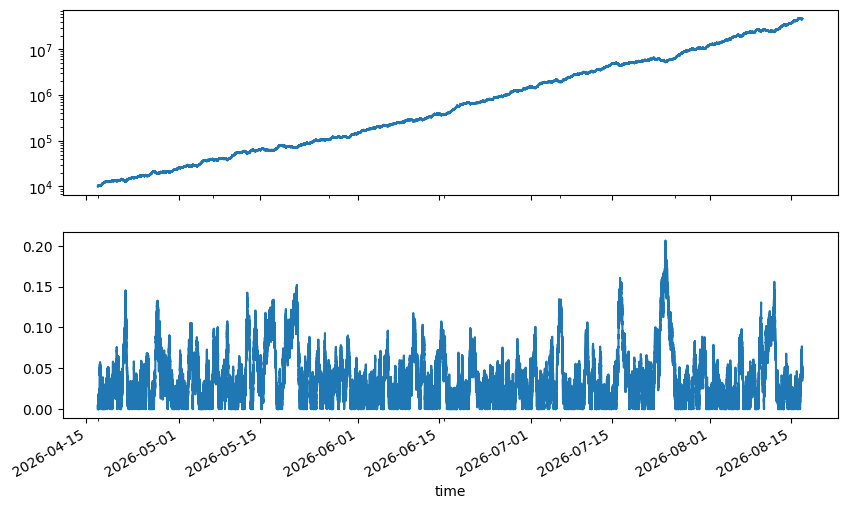

In [22]:
import numpy, matplotlib.pyplot as plot
from pandas import Series, DataFrame
from pandas import Timestamp, Timedelta, date_range

t_start = Timestamp("2026-04-17")
duration = Timedelta(days = 122)
t_end = t_start + duration
index = date_range(t_start, t_end,
    periods = duration.days * 2694, name = "time")
c_start, c_end = 10_000, 48_500_000
ret_ord = numpy.log(c_end / c_start) / len(index)
rand = 1 + numpy.random.randn(len(index)) * 59
df = DataFrame(index = index)
df["ret"] = 1 + ret_ord * rand
df["cret"] = df["ret"].cumprod()
df["bal"] = df["cret"] * c_start
df["bal"] = df["bal"].round(2)
adj = 1 - c_end / df["bal"].max()
adjr = 1 - numpy.linspace(0, 1, df.shape[0]) * adj
df["bal"] = (df["bal"] * adjr).round(2)
df["ret"] = df["bal"].pct_change().fillna(0)
df["cret"] = (df["ret"] + 1).cumprod()
df["bal"] = df["cret"] * c_start
df["bal"] = df["bal"].round(2)
df["ddn"] = 1 - df["bal"] / df["bal"].cummax()
fig = plot.figure(figsize = (10, 6))
ax1, ax2 = fig.subplots(2, sharex = True)
df["bal"].plot(ax = ax1)
ax1.set_yscale("log")
df["ddn"].plot(ax = ax2)
df.index = df.index.strftime("%Y/%m")
df["mret"] = df["ret"].copy()
df["sret"] = df["ret"].copy()
df["xret"] = df["ret"].copy() + 1
dfm = df.groupby("time").agg(dict(
    mret = "mean", sret = "std", xret = "prod",
    cret = "last", bal = "last", ddn = "max")
)
display(dfm); print("Max DDN:", df["ddn"].max())